In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pandas.core.interchange import column

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [2]:
train_df = pd.read_csv("../data/raw/train.csv")
test_df = pd.read_csv("../data/raw/test.csv")

In [3]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
train_df.shape

(891, 12)

In [5]:
train_df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [6]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [17]:
train_df.isnull().mean() * 100

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

In [11]:
train_df.describe(include="all")

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


In [18]:
train_df["Survived"].value_counts(normalize=True) * 100

Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64

## Dataset Overview

*   **Total Samples:** 891
*   **Total Features:** 11
*   **Target Variable:** Binary (2 classes)

---

## Data Quality & Structural Characteristics

### 🔍 Data Anomalies
*   **Missing Values:** Present in the following columns:
    *   `Age`
    *   `Cabin`
    *   `Embarked`
*   **Outliers:** Significant outliers detected in the `Fare` feature.

### 📊 Feature Composition
*   **Mixed Data Types:** Data contains a combination of numerical and categorical variables.
*   **Text Features:** Unstructured text columns are present (requiring vectorization or extraction).
*   **Slight Class Imbalance:** The binary target variable exhibits a minor distributional skew between its two classes.

---

## Summary Profiles

| Profile Element | Details / Affected Features |
| :--- | :--- |
| **Target Type** | Binary Classification |
| **Missing Data** | `Age`, `Cabin`, `Embarked` |
| **Distribution Issues** | Outliers in `Fare`, Mild class imbalance |
| **Data Types** | Mixed (Numeric, Categorical, Text) |


## Visualization 1 — Target Distribution

### Question: Is the Dataset Balanced?

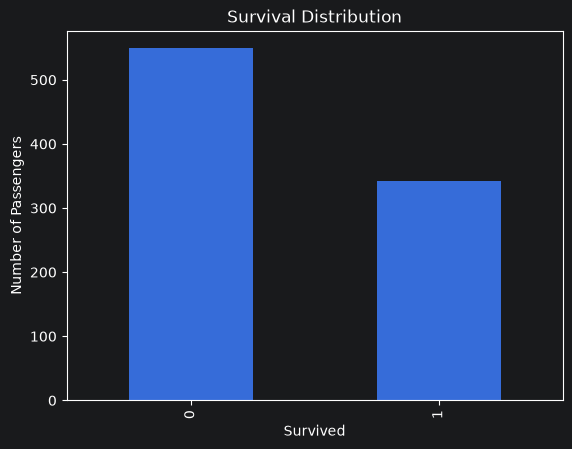

In [19]:
train_df["Survived"].value_counts().plot(kind="bar")

plt.title("Survival Distribution")
plt.xlabel("Survived")
plt.ylabel("Number of Passengers")

plt.show()

## Visualization 2 — Age Distribution

### Question: Is Age Normally Distributed?

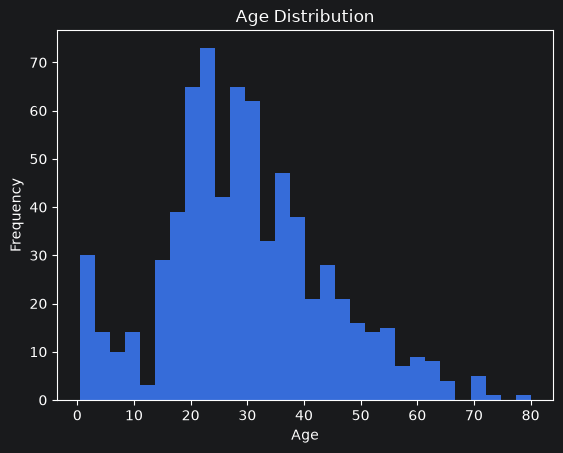

In [20]:
train_df["Age"].plot(kind="hist", bins=30)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

## Visualization 3 — Age Boxplot

### Question: Are there outliers?

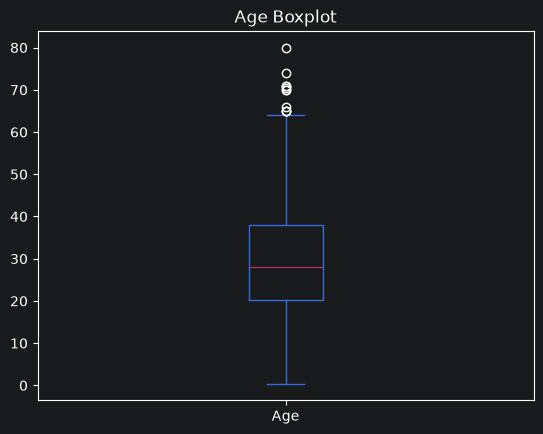

In [21]:
train_df["Age"].plot(kind="box")

plt.title("Age Boxplot")

plt.show()

## Visualization 4 — Fare Distribution

### Question: Is Fare Normally Distributed or Skewed?

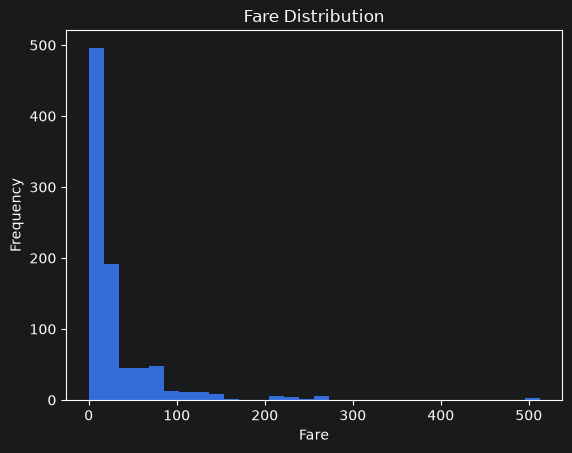

In [22]:
train_df["Fare"].plot(kind="hist", bins=30)

plt.title("Fare Distribution")
plt.xlabel("Fare")

plt.show()

## Visualization 5 — Fare Boxplot

### Question: Are there outliers?

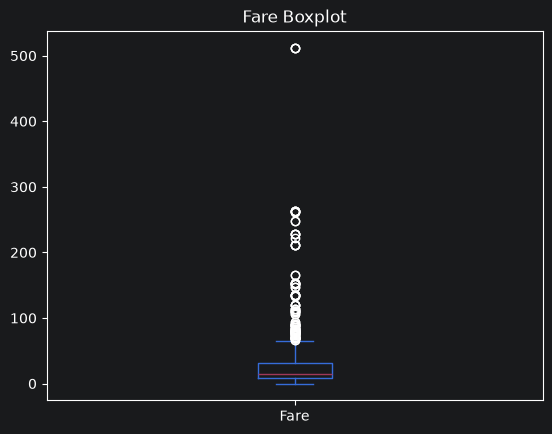

In [23]:
train_df["Fare"].plot(kind="box")

plt.title("Fare Boxplot")
plt.show()

## Visualization 6 — Survival By Sex

### Question: Does survival rate vary by sex?

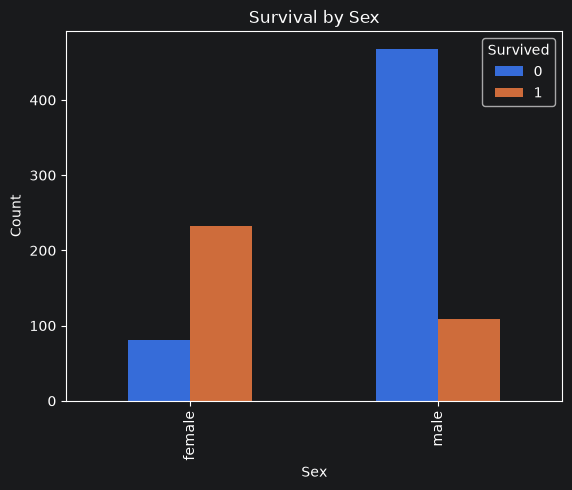

In [26]:
survival_by_sex = pd.crosstab(
    train_df["Sex"],
    train_df["Survived"]
)
survival_by_sex.plot(kind="bar")

plt.title("Survival by Sex")
plt.xlabel("Sex")
plt.ylabel("Count")

plt.show()

## Visualization 7 — Survival By Passenger Class

### Question: Which class survived the most?

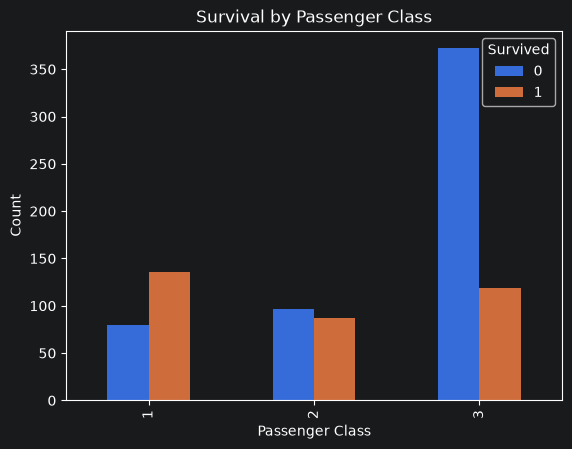

In [27]:
survived_by_class = pd.crosstab(
    train_df["Pclass"],
    train_df["Survived"]
)

survived_by_class.plot(kind="bar")

plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Count")

plt.show()

## Dataset Insights & Distributions

*   **Target Variable:** Moderate class imbalance present.

---

## Feature Profiles

### 👤 Age
*   Contains missing values.
*   Exhibits a slight right skew in its distribution.

### 💵 Fare
*   Contains large outliers.
*   Highly right-skewed, requiring transformation (e.g., log transform).

### 🚪 Cabin
*   Data is mostly missing (high sparsity, may require dropping or indicator variables).

---

## 📈 Survival Trends (Key Associations)

*   **Gender Effect:** Female survival rate is significantly higher than male survival rate (`Female survival > Male`).
*   **Socioeconomic Effect:** Strong correlation between class status and survival probability (`1st Class survival > 2nd > 3rd`).

---

## Summary Profiles

| Profile Element | Operational Impact / Details |
| :--- | :--- |
| **Class Distribution** | Moderate imbalance (consider stratified splitting or sampling adjustments) |
| **High Sparsity** | `Cabin` (mostly missing) |
| **Skewed Numeric Features** | `Age` (slight), `Fare` (high + large outliers) |
| **Strong Predictive Signals** | Gender (Female) and Passenger Class (1st Class) |


## Bivariate EDA

### Question 1: Does Age Influence Survival?

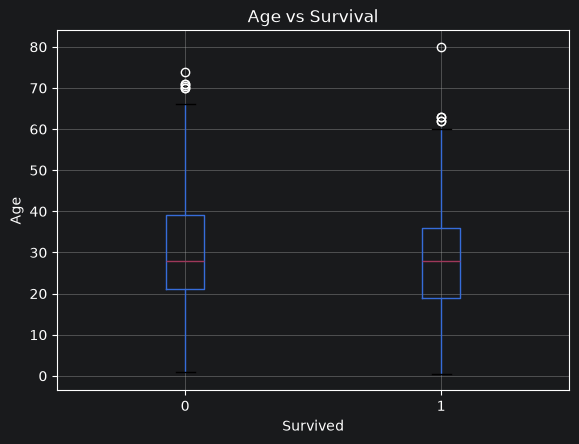

In [28]:
train_df.boxplot(column="Age", by="Survived")

plt.title("Age vs Survival")
plt.suptitle("")
plt.xlabel("Survived")
plt.ylabel("Age")

plt.show()

### Question 2: Does Fare Influence Survival?

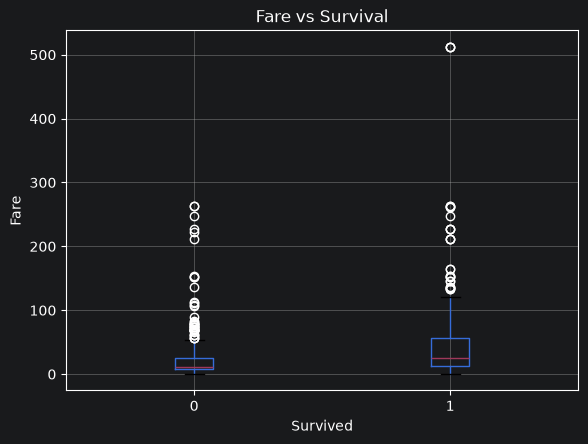

In [29]:
train_df.boxplot(column="Fare", by="Survived")

plt.title("Fare vs Survival")
plt.suptitle("")
plt.xlabel("Survived")
plt.ylabel("Fare")

plt.show()

### Question 3: Does Passenger Class influence Survival?

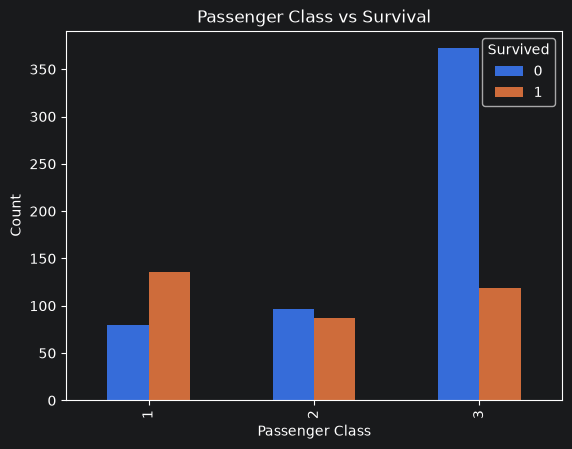

In [30]:
pd.crosstab(
    train_df["Pclass"],
    train_df["Survived"]
).plot(kind="bar")

plt.title("Passenger Class vs Survival")
plt.xlabel("Passenger Class")
plt.ylabel("Count")

plt.show()

### Question 4: Does Embarked influence Survival?

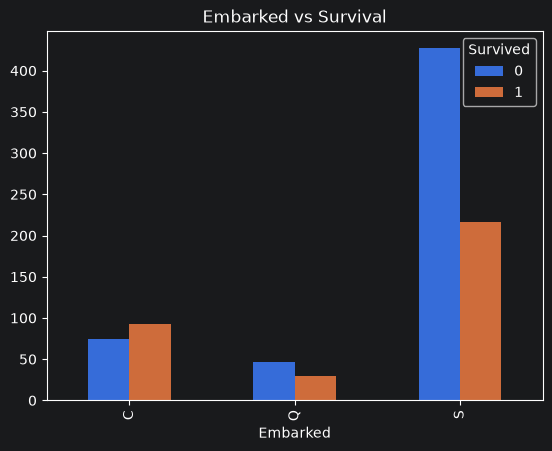

In [31]:
pd.crosstab(
    train_df["Embarked"],
    train_df["Survived"]
).plot(kind="bar")

plt.title("Embarked vs Survival")

plt.show()

### Question 5: Does Family Size Matter?

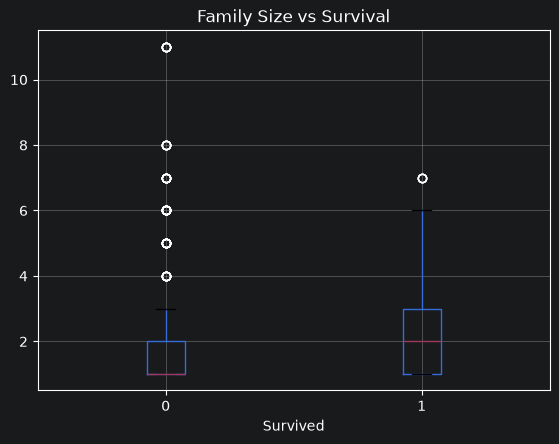

In [32]:
train_df["FamilySize"] = (
    train_df["SibSp"] +
    train_df["Parch"] +
    1
)

train_df.boxplot(column="FamilySize", by="Survived")

plt.title("Family Size vs Survival")
plt.suptitle("")

plt.show()

## Dataset Exploration — Key Findings

*   **Total Sample Count:** 891 entries with 11 operational features.
*   **Target Vector:** `Survived` exhibits a mild class imbalance (approx. 61.6% Non-survived vs 38.4% Survived).

---

## Technical Feature Profiling & Data Quality

### 🔍 Missing Data & Structural Challenges
*   **Feature Sparsity:** `Cabin` values are highly missing (~77.1%), rendering it highly sparse.
*   **Imputation Requirements:** `Age` (~19.9%) and `Embarked` (~0.2%) contain missing rows that will require feature imputation during pre-processing.
*   **Distributional Skew:** `Fare` exhibits a severe right-skew distribution containing extreme outliers, signaling the necessity for transformation (e.g., log transform).

---

## 📉 Predictive Signals & Operational Logic

| Feature Context | Core Data Insights / Operational Impact |
| :--- | :--- |
| **Gender-Based Distribution** | Female survival counts significantly exceed male survival, indicating that `Sex` will serve as a strong predictive feature. |
| **Socioeconomic Distribution** | Lower socioeconomic classes (3rd Class) show high non-survival rates compared to upper classes (1st Class), rendering `Pclass` highly correlative to target status. |
| **Family Structures** | Feature engineering around total family size (`SibSp` + `Parch` + 1) shows localized variations across overall survival trends. |